# Advanced Traffic Evolution Analysis

This notebook extends the evolution study with a more detailed comparison of stations and road segments. It helps identify areas with sustained growth, unusual stability, or behavior that differs from the broader highway network.

### Step 4: Compare stations in detail
This section provides a deeper comparison of road segments and station behavior.

In [1]:
# Compare station-level traffic evolution in detail
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [2]:
# Compare station-level traffic evolution in detail
df = pd.read_csv("../data/traffic_cleaned_final.csv")

print(df.shape)

(34451, 252)


C:\Users\vikhy\AppData\Local\Temp\ipykernel_15296\3462123713.py:1: DtypeWarning: Columns (0: Ri_MSV30maxRi_Kfz_MobisSo, 1: Ri_MSV30maxRi_Kfz_W, 2: Ri_MSV30maxRi_Kfz_U, 3: Ri_MSV30maxRi_Kfz_S, 4: DL_Q, 5: bSV30_MobisSo_Ri1, 6: bSV30_MobisSo_Ri2, 7: bSV30_W_Ri1, 8: bSV30_W_Ri2, 9: bSV30_U_Ri1, 10: bSV30_U_Ri2, 11: bSV30_S_Ri1, 12: bSV30_S_Ri2, 13: bSV50_MobisSo_Ri1, 14: bSV50_MobisSo_Ri2, 15: bLkwK50_MobisSo_Ri1, 16: bLkwK50_MobisSo_Ri2, 17: Abschnitt_Ast, 18: Station, 19: Ausrichtung) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/traffic_cleaned_final.csv")


In [ ]:
#filter only required roads
#selected as given in project ppt
selected_roads = [6,9,93]

traffic = df[
    df["Str_Nr"].isin(selected_roads)
].copy()

traffic.shape

(2779, 252)

In [ ]:
# Compare station-level traffic evolution in detail
#AI usage :generate me summaary of rows,years,stations and roads in the dataset
print("="*60)

print("TRAFFIC EVOLUTION DATASET")

print("="*60)

print(f"Rows               : {len(traffic)}")

print(f"Years              : {traffic['Jahr'].nunique()}")

print(f"Stations           : {traffic['DZ_Name'].nunique()}")

print(f"Roads              : {traffic['Str_Nr'].unique()}")

TRAFFIC EVOLUTION DATASET
Rows               : 2779
Years              : 21
Stations           : 177
Roads              : [ 6  9 93]


In [7]:
#count stations
traffic.groupby("Str_Nr")["DZ_Name"].nunique()

Str_Nr
6     80
9     83
93    14
Name: DZ_Name, dtype: int64

In [ ]:
#Data quality check
#AI usage : give me code to check the quality if data
missing_before = traffic["DTV_Kfz_W_Q"].isna().sum()

print("="*50)

print("DATA QUALITY REPORT")

print("="*50)

print(f"Rows before cleaning : {len(traffic)}")

print(f"Missing traffic rows : {missing_before}")

traffic = traffic.dropna(
    subset=["DTV_Kfz_W_Q"]
)

print(f"Rows after cleaning : {len(traffic)}")

DATA QUALITY REPORT
Rows before cleaning : 2779
Missing traffic rows : 385
Rows after cleaning : 2394


In [9]:
#missing percentage
missing_percent = (
    missing_before /
    (len(traffic)+missing_before)
)*100

print(f"Missing Percentage : {missing_percent:.2f}%")

Missing Percentage : 13.85%


In [10]:
#records per road
records = traffic["Str_Nr"].value_counts()

records

Str_Nr
9     1135
6     1019
93     240
Name: count, dtype: int64

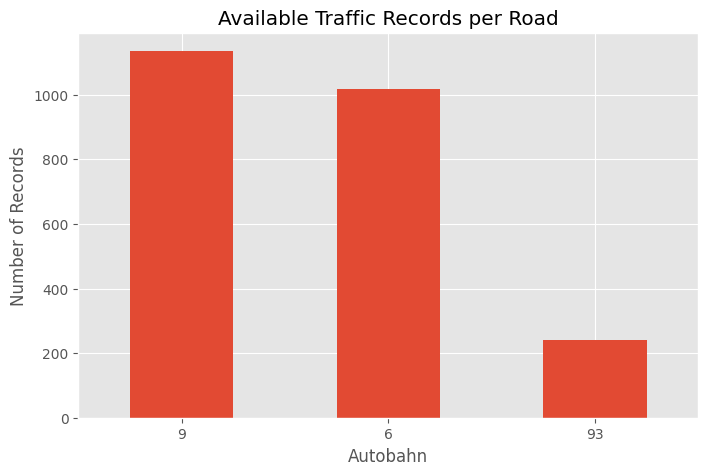

In [11]:
# Compare station-level traffic evolution in detail
plt.figure(figsize=(8,5))

records.plot(kind="bar")

plt.title("Available Traffic Records per Road")

plt.xlabel("Autobahn")

plt.ylabel("Number of Records")

plt.xticks(rotation=0)

plt.show()

In [ ]:
#average yearly traffic 
#AI usage : give me code to calculate average yearly traffic for each road
yearly = (
    traffic
    .groupby(
        ["Jahr","Str_Nr"]
    )["DTV_Kfz_W_Q"]
    .mean()
    .reset_index()
)

In [ ]:
# Compare station-level traffic evolution in detail
pivot = yearly.pivot(
    index="Jahr",
    columns="Str_Nr",
    values="DTV_Kfz_W_Q"
)

pivot.head()

Str_Nr,6,9,93
Jahr,,,
2003,40.741486,50.959829,40.662500
2004,40.735140,48.178268,40.105091
2005,39.840372,48.195500,38.860545
2006,37.144581,58.402313,38.900833
2007,37.616791,60.003321,39.807000


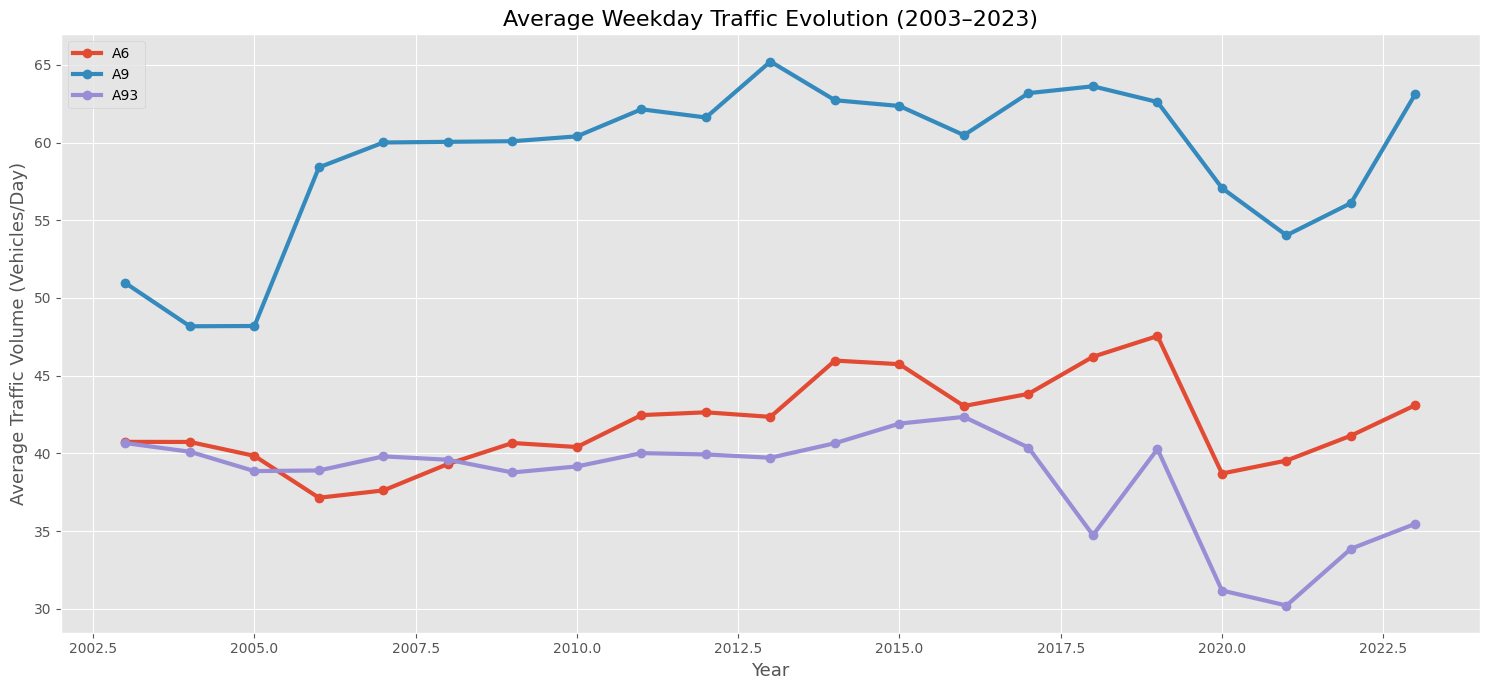

In [ ]:
# Compare station-level traffic evolution in detail
#AI-assisted: Initial plotting code function generated with ChatGPT 
plt.figure(figsize=(15,7))

colors = {
    6:"blue",
    9:"red",
    93:"green"
}

for road in pivot.columns:

    plt.plot(
        pivot.index,
        pivot[road],
        marker="o",
        linewidth=3,
        label=f"A{road}"
    )

plt.title(
    "Average Weekday Traffic Evolution (2003–2023)",
    fontsize=16
)

plt.xlabel(
    "Year",
    fontsize=13
)

plt.ylabel(
    "Average Traffic Volume (Vehicles/Day)",
    fontsize=13
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [ ]:
# Compare station-level traffic evolution in detail
#AI assitance : give me code to compare station level traffic
growth = (
    (
        pivot.iloc[-1] -
        pivot.iloc[0]
    )
    /
    pivot.iloc[0]
)*100

growth

Str_Nr
6      5.807305
9     23.910510
93   -12.755443
dtype: float64

In [16]:
# Compare station-level traffic evolution in detail
growth = growth.round(2)

growth = growth.rename(
    "Growth (%)"
)

growth

Str_Nr
6      5.81
9     23.91
93   -12.76
Name: Growth (%), dtype: float64

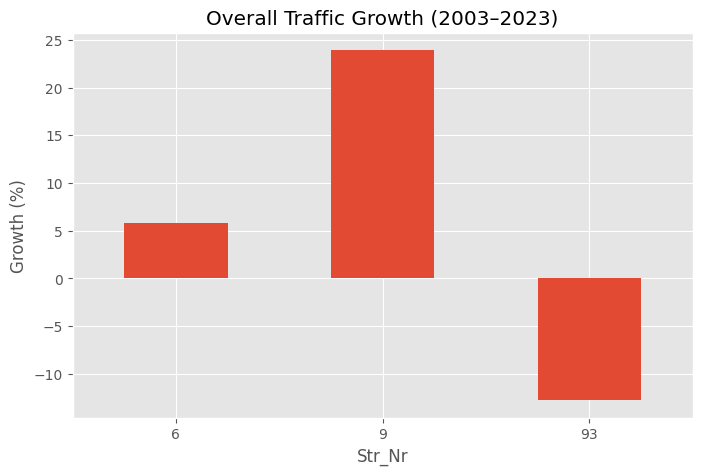

In [17]:
# Compare station-level traffic evolution in detail
plt.figure(figsize=(8,5))

growth.plot(kind="bar")

plt.title("Overall Traffic Growth (2003–2023)")

plt.ylabel("Growth (%)")

plt.xticks(rotation=0)

plt.show()

In [18]:
# Compare station-level traffic evolution in detail
yearly_growth = pivot.pct_change()*100

yearly_growth.head()

Str_Nr,6,9,93
Jahr,,,
2003,NaN,NaN,NaN
2004,-0.015577,-5.458339,-1.370819
2005,-2.196549,0.035767,-3.103211
2006,-6.766480,21.177937,0.103673
2007,1.271274,2.741344,2.329427


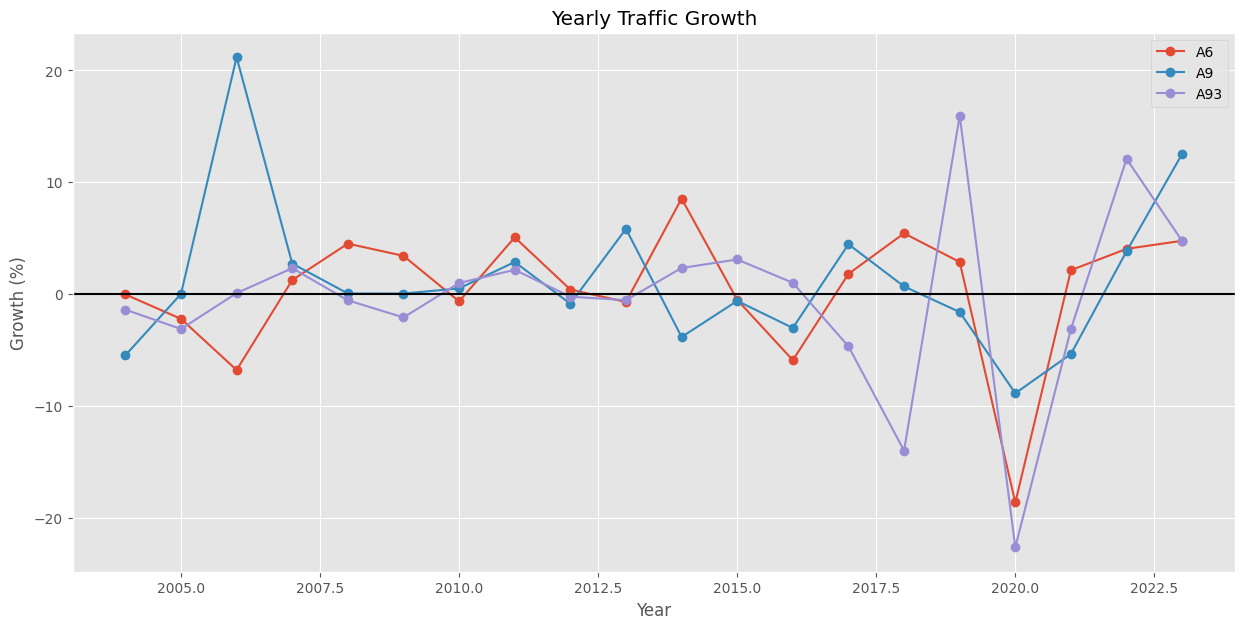

In [19]:
# Compare station-level traffic evolution in detail
plt.figure(figsize=(15,7))

for road in yearly_growth.columns:

    plt.plot(
        yearly_growth.index,
        yearly_growth[road],
        marker="o",
        label=f"A{road}"
    )

plt.axhline(0,color="black")

plt.title("Yearly Traffic Growth")

plt.xlabel("Year")

plt.ylabel("Growth (%)")

plt.legend()

plt.grid(True)

plt.show()

In [20]:
# Compare station-level traffic evolution in detail
stations = (
    traffic
    .groupby(
        ["Jahr","Str_Nr"]
    )
    ["DZ_Name"]
    .nunique()
    .reset_index()
)

In [21]:
# Compare station-level traffic evolution in detail
station_pivot = stations.pivot(
    index="Jahr",
    columns="Str_Nr",
    values="DZ_Name"
)

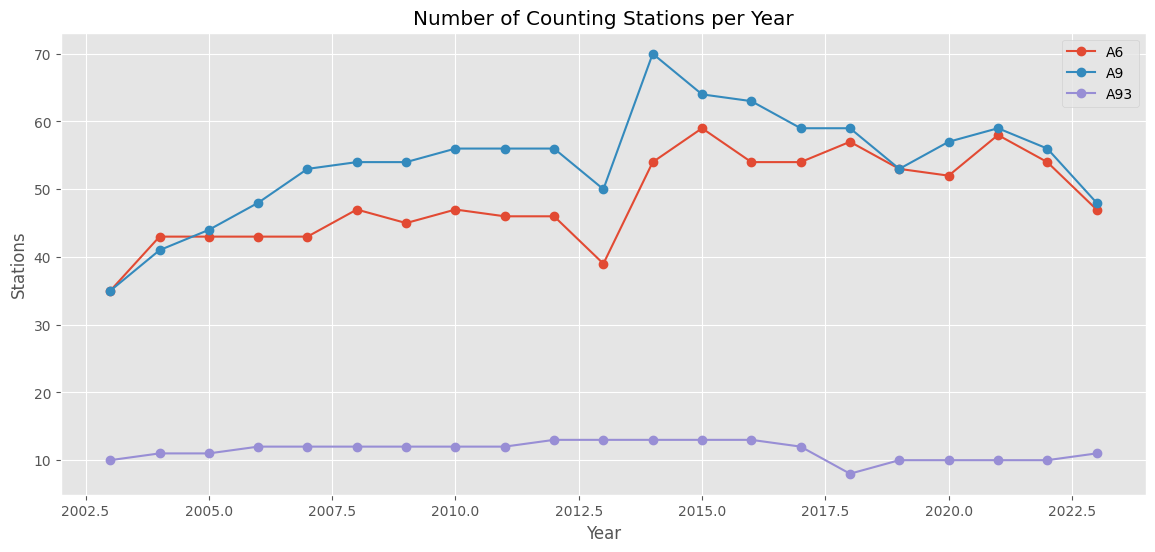

In [22]:
# Compare station-level traffic evolution in detail
plt.figure(figsize=(14,6))

for road in station_pivot.columns:

    plt.plot(
        station_pivot.index,
        station_pivot[road],
        marker="o",
        label=f"A{road}"
    )

plt.title(
    "Number of Counting Stations per Year"
)

plt.ylabel("Stations")

plt.xlabel("Year")

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
#AI usage : I want to see Heavy vehicle trend and plot a graph of evolution
#Heavy vehicle trend
heavy = (
    traffic
    .groupby(
        ["Jahr","Str_Nr"]
    )
    ["DTV_SV_W_Q"]
    .mean()
    .reset_index()
)

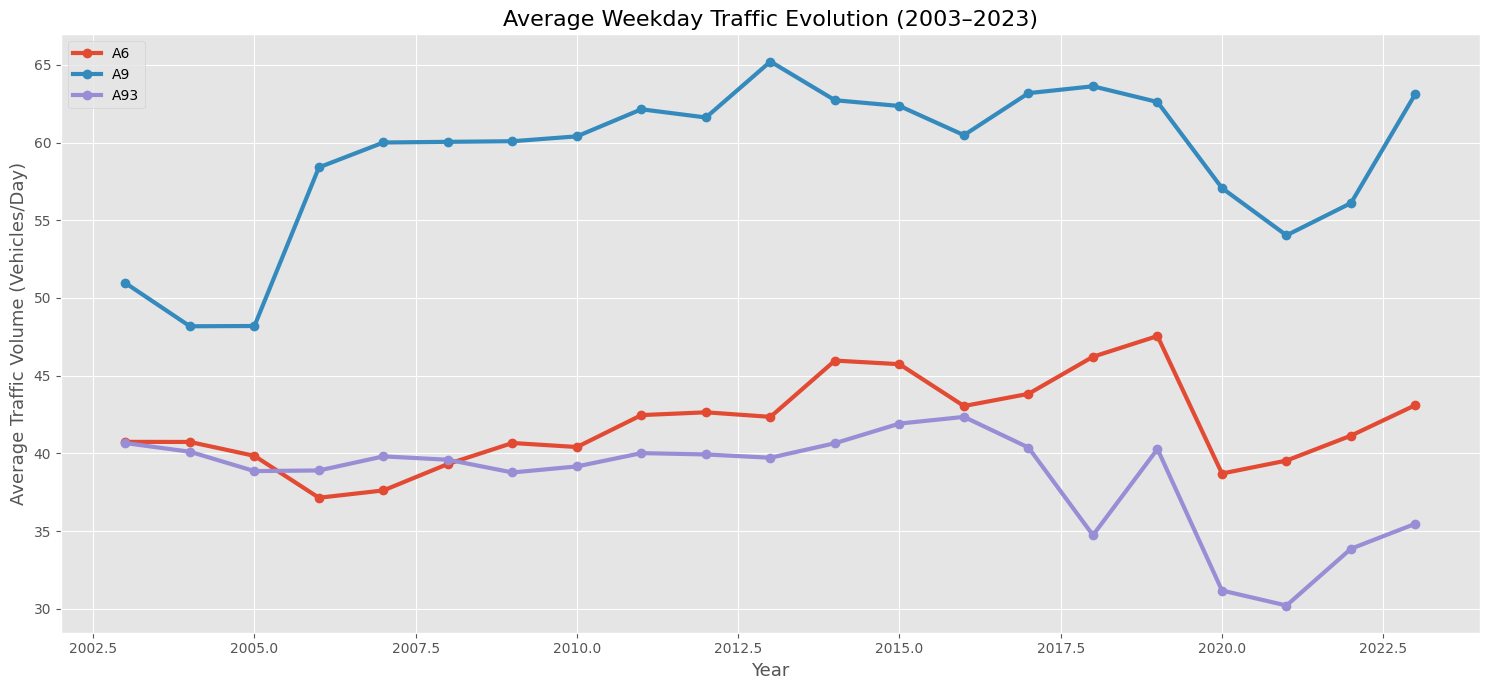

In [24]:
# Compare station-level traffic evolution in detail
plt.figure(figsize=(15,7))

colors = {
    6:"blue",
    9:"red",
    93:"green"
}

for road in pivot.columns:

    plt.plot(
        pivot.index,
        pivot[road],
        marker="o",
        linewidth=3,
        label=f"A{road}"
    )

plt.title(
    "Average Weekday Traffic Evolution (2003–2023)",
    fontsize=16
)

plt.xlabel(
    "Year",
    fontsize=13
)

plt.ylabel(
    "Average Traffic Volume (Vehicles/Day)",
    fontsize=13
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [25]:
# Compare station-level traffic evolution in detail
truck = (
    traffic
    .groupby(
        ["Jahr","Str_Nr"]
    )
    ["pSV_W_Q"]
    .mean()
    .reset_index()
)

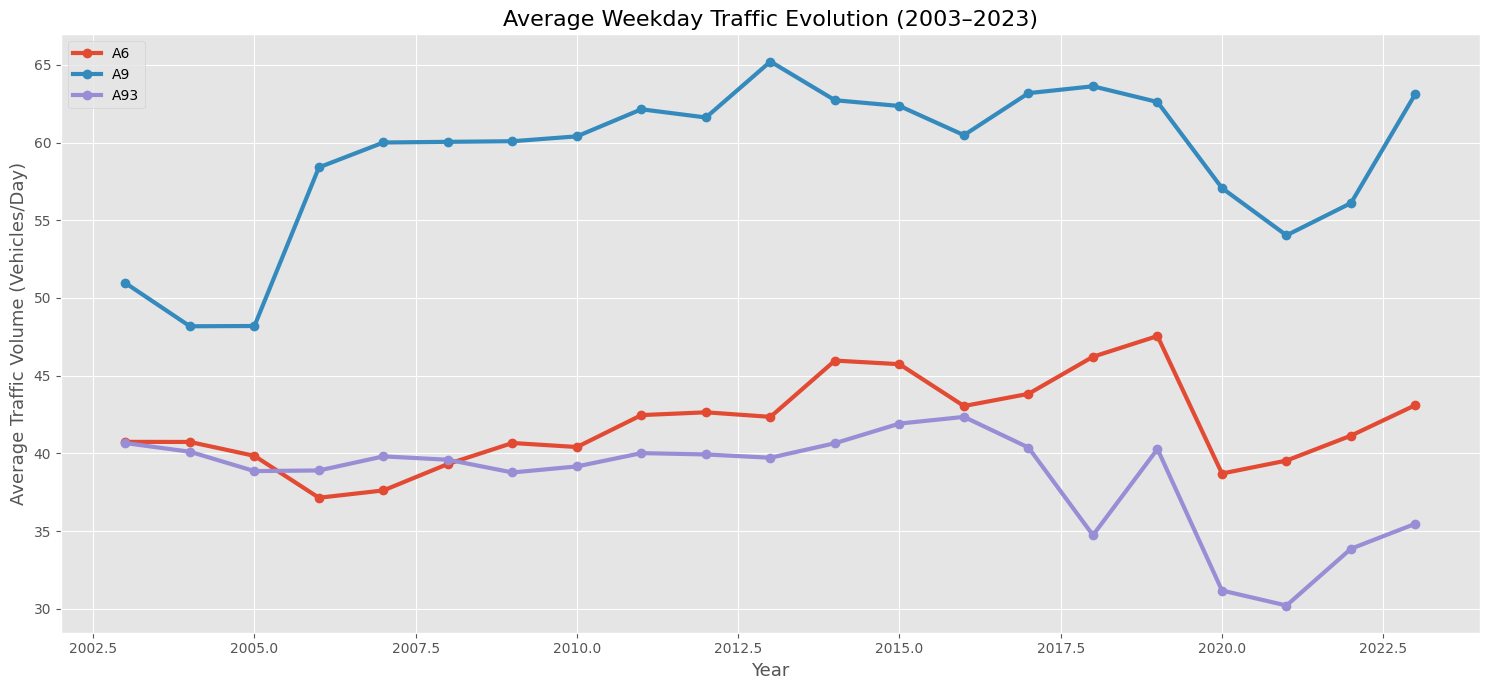

In [27]:
# Compare station-level traffic evolution in detail
summary = (
    traffic
    .groupby("Str_Nr")
    .agg(
        Mean=("DTV_Kfz_W_Q","mean"),
        Median=("DTV_Kfz_W_Q","median"),
        Maximum=("DTV_Kfz_W_Q","max"),
        Minimum=("DTV_Kfz_W_Q","min"),
        Std=("DTV_Kfz_W_Q","std")
    )
)

summary

,Mean,Median,Maximum,Minimum,Std
Str_Nr,,,,,
6,42.030973,43.8080,103.735,2.478,24.445103
9,59.495539,58.2300,161.527,3.320,34.919984
93,38.656750,37.3325,75.655,5.374,18.813721


In [28]:
# Compare station-level traffic evolution in detail
traffic.loc[
    traffic.groupby("Str_Nr")
    ["DTV_Kfz_W_Q"]
    .idxmax(),
    ["Str_Nr","Jahr","DZ_Name","DTV_Kfz_W_Q"]
]

,Str_Nr,Jahr,DZ_Name,DTV_Kfz_W_Q
330,6,2023,Neckarsulm 1,103.735
19518,9,2013,AK München-Nord (N),161.527
14899,93,2016,AK Regensburg (N),75.655


In [29]:
# Compare station-level traffic evolution in detail
print("="*60)
print("INTERPRETATION")
print("="*60)

for road in growth.index:

    if growth.loc[road] > 0:
        print(f"A{road}: Traffic increased by {growth.loc[road]:.2f}% over the study period.")
    else:
        print(f"A{road}: Traffic decreased by {abs(growth.loc[road]):.2f}% over the study period.")

INTERPRETATION
A6: Traffic increased by 5.81% over the study period.
A9: Traffic increased by 23.91% over the study period.
A93: Traffic decreased by 12.76% over the study period.


In [ ]:
# Compare station-level traffic evolution in detail
#AI usage : Generate a summary for this 03_traffic_evolution notebook   
print("="*60)
print("CONCLUSION")
print("="*60)

print(f"""
• Analysis period: {traffic['Jahr'].min()}–{traffic['Jahr'].max()}

• Roads analysed: A6, A9 and A93

• Missing traffic records removed: {missing_before}

• Final observations analysed: {len(traffic)}

• The traffic evolution plots show how average weekday traffic changed over the study period.

• Growth calculations indicate which road experienced the strongest increase in traffic.

• Heavy vehicle analysis provides additional insight into freight transport trends.

• Station count analysis confirms whether observed changes are influenced by changes in the monitoring network.
""")

CONCLUSION

• Analysis period: 2003–2023

• Roads analysed: A6, A9 and A93

• Missing traffic records removed: 385

• Final observations analysed: 2394

• The traffic evolution plots show how average weekday traffic changed over the study period.

• Growth calculations indicate which road experienced the strongest increase in traffic.

• Heavy vehicle analysis provides additional insight into freight transport trends.

• Station count analysis confirms whether observed changes are influenced by changes in the monitoring network.

